# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Loading and Saving
from moments.bloch import (compute_bipartite_region_upper, compute_bipartite_region_ent, compute_bipartite_region_lower)
from moments.quantum import compute_negativity
from moments.saving import get_experiment_paths

data_dir, plots_dir = get_experiment_paths(__vsc_ipynb_file__)

# Concurrence

## Importations and definitions

In [2]:
ent = np.load(data_dir / "concurrence.npz")
ent_max, ent_min = ent["max"], ent["min"]

Dx, Dz = ent_max.shape

x = np.linspace(0, 1, Dx)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

## Plots

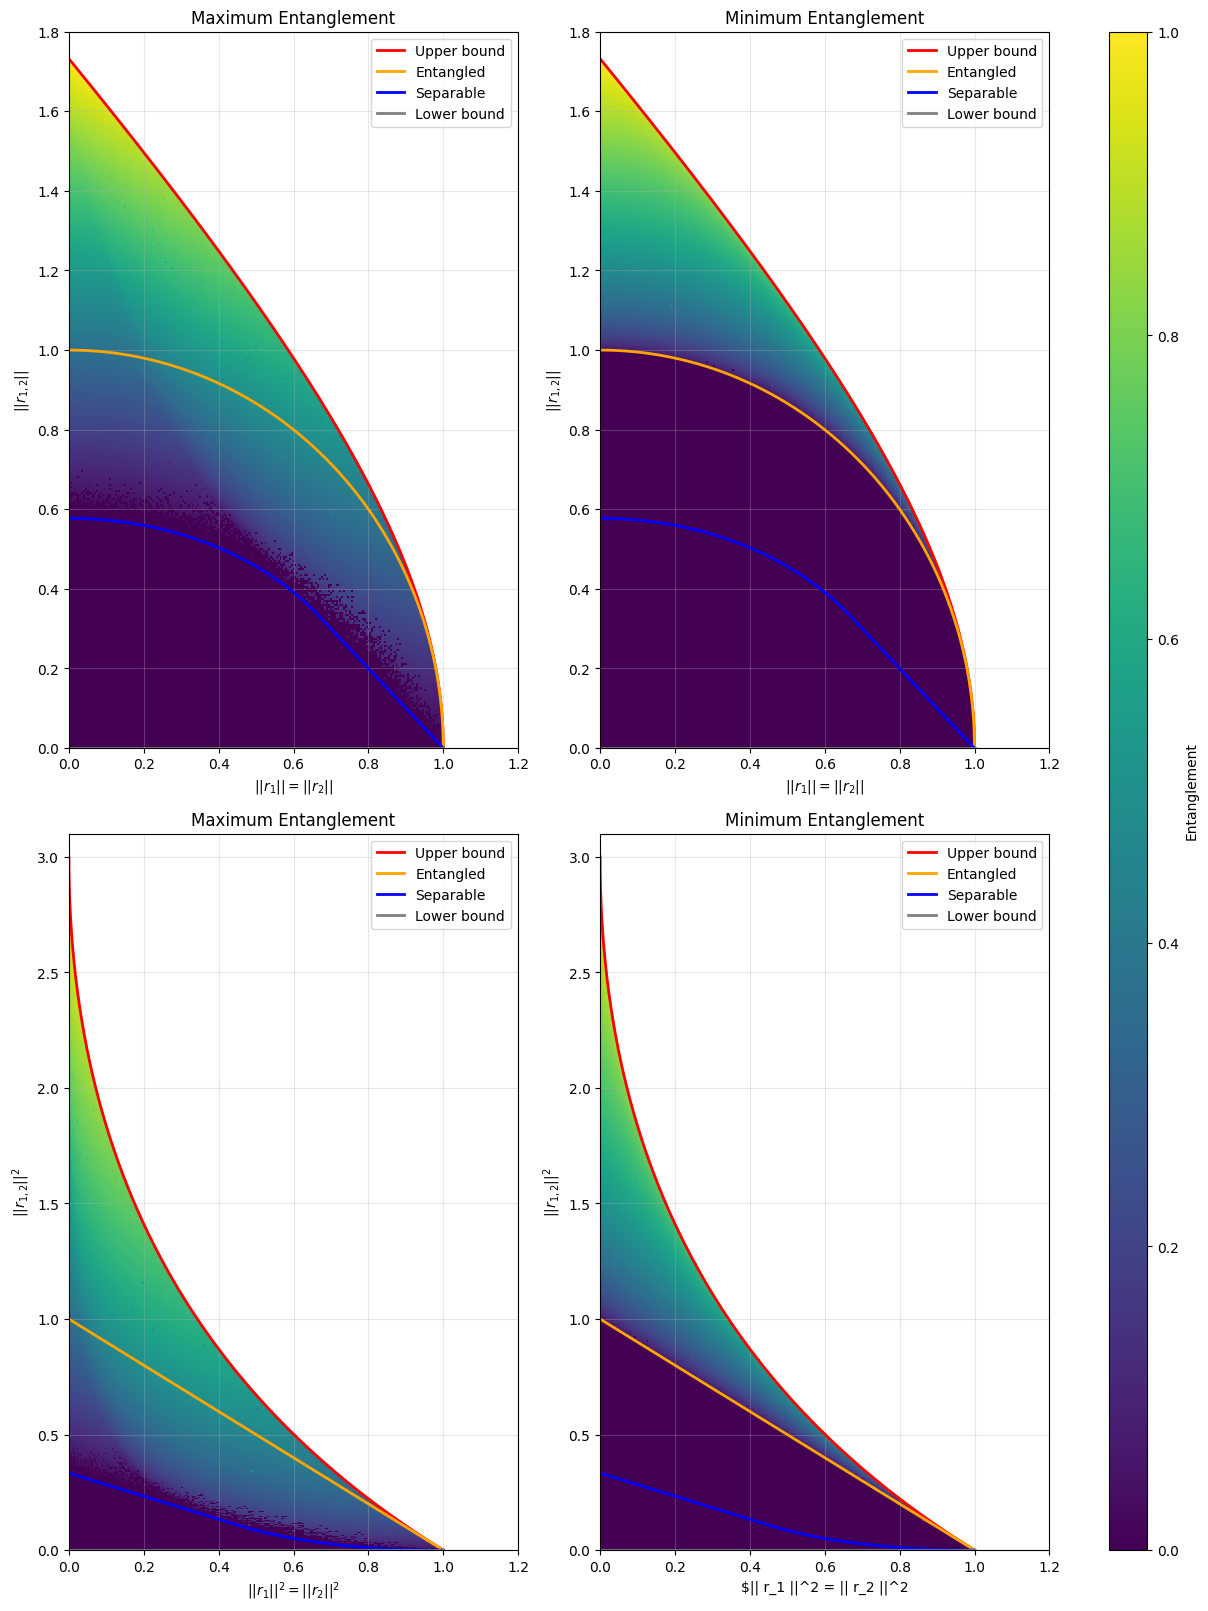

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 16), constrained_layout=True)

mesh0 = ax[0, 0].pcolormesh(X, Z, ent_max, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[0, 1].pcolormesh(X, Z, ent_min, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh2 = ax[1, 0].pcolormesh(X**2, Z**2, ent_max, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh3 = ax[1, 1].pcolormesh(X**2, Z**2, ent_min, shading='auto', cmap='viridis', vmin=0, vmax=1)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=40, shrink=1)

cbar.set_ticks(list(np.linspace(0, 1, 6)))

ax[0, 0].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.2), ylim = (0, 1.8), title = "Maximum Entanglement")
ax[0, 1].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.2), ylim = (0, 1.8), title = "Minimum Entanglement")
ax[1, 0].set(xlabel = r"$|| r_1 ||^2 = || r_2 ||^2$", ylabel = r"$||r_{1, 2}||^2$",
             xlim = (0, 1.2), ylim = (0, 3.1), title = "Maximum Entanglement")
ax[1, 1].set(xlabel = r"$|| r_1 ||^2 = || r_2 ||^2", ylabel = r"$||r_{1, 2}||^2$",
             xlim = (0, 1.2), ylim = (0, 3.1), title = "Minimum Entanglement")

x = np.linspace(0, 1, 1000)
z_upper = compute_bipartite_region_upper(2, x, 0)
z_ent = compute_bipartite_region_ent(2, x, 0)
z_sep = np.piecewise(x, [x <= 2/3, x > 2/3], [lambda x: np.sqrt(1/6 * (2 - 3 * x**2)), lambda x: 1 - x])
z_lower = compute_bipartite_region_lower([2, 2], x, 0)

ax[0, 0].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 0].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 0].plot(x, z_sep, 'blue', linewidth=2, label='Separable')
ax[0, 0].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

ax[0, 1].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 1].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 1].plot(x, z_sep, 'blue', linewidth=2, label='Separable')
ax[0, 1].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

ax[1, 0].plot(x**2, z_upper**2, 'red', linewidth=2, label='Upper bound')
ax[1, 0].plot(x**2, z_ent**2, 'orange', linewidth=2, label='Entangled')
ax[1, 0].plot(x**2, z_sep**2, 'blue', linewidth=2, label='Separable')
ax[1, 0].plot(x**2, z_lower**2, 'grey', linewidth=2, label='Lower bound')

ax[1, 1].plot(x**2, z_upper**2, 'red', linewidth=2, label='Upper bound')
ax[1, 1].plot(x**2, z_ent**2, 'orange', linewidth=2, label='Entangled')
ax[1, 1].plot(x**2, z_sep**2, 'blue', linewidth=2, label='Separable')
ax[1, 1].plot(x**2, z_lower**2, 'grey', linewidth=2, label='Lower bound')

ax[0, 0].legend(loc='upper right')
ax[0, 1].legend(loc='upper right')
ax[1, 0].legend(loc='upper right')
ax[1, 1].legend(loc='upper right')
ax[0, 0].grid(True, alpha=0.3)
ax[0, 1].grid(True, alpha=0.3)
ax[1, 0].grid(True, alpha=0.3)
ax[1, 1].grid(True, alpha=0.3)

plt.show()

# Negativity

## Importations and definitions

In [3]:
ent_num = np.load(data_dir / "trace_norm_exact.npz")
ent_exact = np.load(data_dir / "trace_norm_exact.npz")

ent_max_num = compute_negativity(trace_norm_pt=ent_num["max"])
ent_min_num = compute_negativity(trace_norm_pt=ent_num["min"])
ent_max_exact = compute_negativity(trace_norm_pt=ent_exact["max"])
ent_min_exact = compute_negativity(trace_norm_pt=ent_exact["min"])

Dx, Dz = ent_num["max"].shape
x = np.linspace(0, 1, Dx)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

## Plots

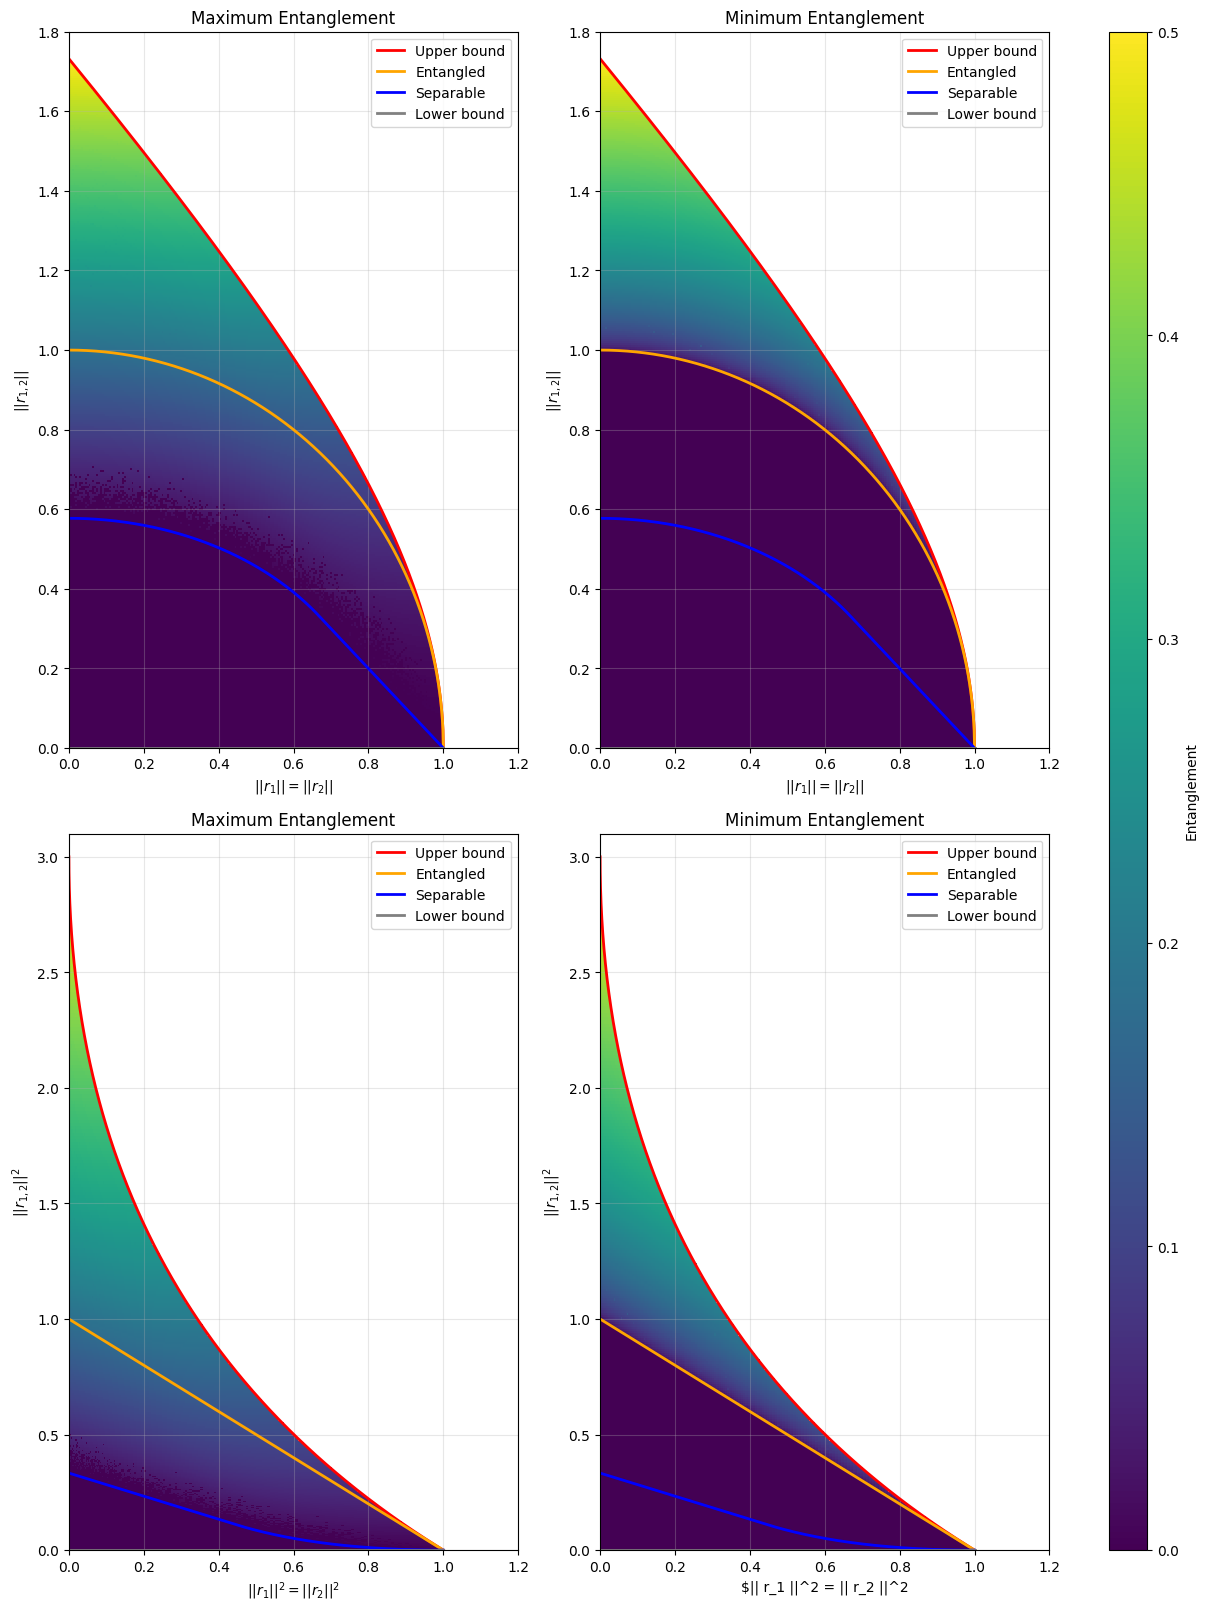

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(12, 16), constrained_layout=True)

mesh0 = ax[0, 0].pcolormesh(X, Z, ent_max_num, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
mesh1 = ax[0, 1].pcolormesh(X, Z, ent_min_num, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
mesh2 = ax[1, 0].pcolormesh(X**2, Z**2, ent_max_num, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
mesh3 = ax[1, 1].pcolormesh(X**2, Z**2, ent_min_num, shading='auto', cmap='viridis', vmin=0, vmax=0.5)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=40, shrink=1)

cbar.set_ticks(list(np.linspace(0, 0.5, 6)))

ax[0, 0].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.2), ylim = (0, 1.8), title = "Maximum Entanglement")
ax[0, 1].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.2), ylim = (0, 1.8), title = "Minimum Entanglement")
ax[1, 0].set(xlabel = r"$|| r_1 ||^2 = || r_2 ||^2$", ylabel = r"$||r_{1, 2}||^2$",
             xlim = (0, 1.2), ylim = (0, 3.1), title = "Maximum Entanglement")
ax[1, 1].set(xlabel = r"$|| r_1 ||^2 = || r_2 ||^2", ylabel = r"$||r_{1, 2}||^2$",
             xlim = (0, 1.2), ylim = (0, 3.1), title = "Minimum Entanglement")

x = np.linspace(0, 1, 1000)
z_upper = compute_bipartite_region_upper(2, x, 0)
z_ent = compute_bipartite_region_ent(2, x, 0)
z_sep = np.piecewise(x, [x <= 2/3, x > 2/3], [lambda x: np.sqrt(1/6 * (2 - 3 * x**2)), lambda x: 1 - x])
z_lower = compute_bipartite_region_lower([2, 2], x, 0)

ax[0, 0].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 0].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 0].plot(x, z_sep, 'blue', linewidth=2, label='Separable')
ax[0, 0].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

ax[0, 1].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 1].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 1].plot(x, z_sep, 'blue', linewidth=2, label='Separable')
ax[0, 1].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

ax[1, 0].plot(x**2, z_upper**2, 'red', linewidth=2, label='Upper bound')
ax[1, 0].plot(x**2, z_ent**2, 'orange', linewidth=2, label='Entangled')
ax[1, 0].plot(x**2, z_sep**2, 'blue', linewidth=2, label='Separable')
ax[1, 0].plot(x**2, z_lower**2, 'grey', linewidth=2, label='Lower bound')

ax[1, 1].plot(x**2, z_upper**2, 'red', linewidth=2, label='Upper bound')
ax[1, 1].plot(x**2, z_ent**2, 'orange', linewidth=2, label='Entangled')
ax[1, 1].plot(x**2, z_sep**2, 'blue', linewidth=2, label='Separable')
ax[1, 1].plot(x**2, z_lower**2, 'grey', linewidth=2, label='Lower bound')

ax[0, 0].legend(loc='upper right')
ax[0, 1].legend(loc='upper right')
ax[1, 0].legend(loc='upper right')
ax[1, 1].legend(loc='upper right')
ax[0, 0].grid(True, alpha=0.3)
ax[0, 1].grid(True, alpha=0.3)
ax[1, 0].grid(True, alpha=0.3)
ax[1, 1].grid(True, alpha=0.3)

plt.show()

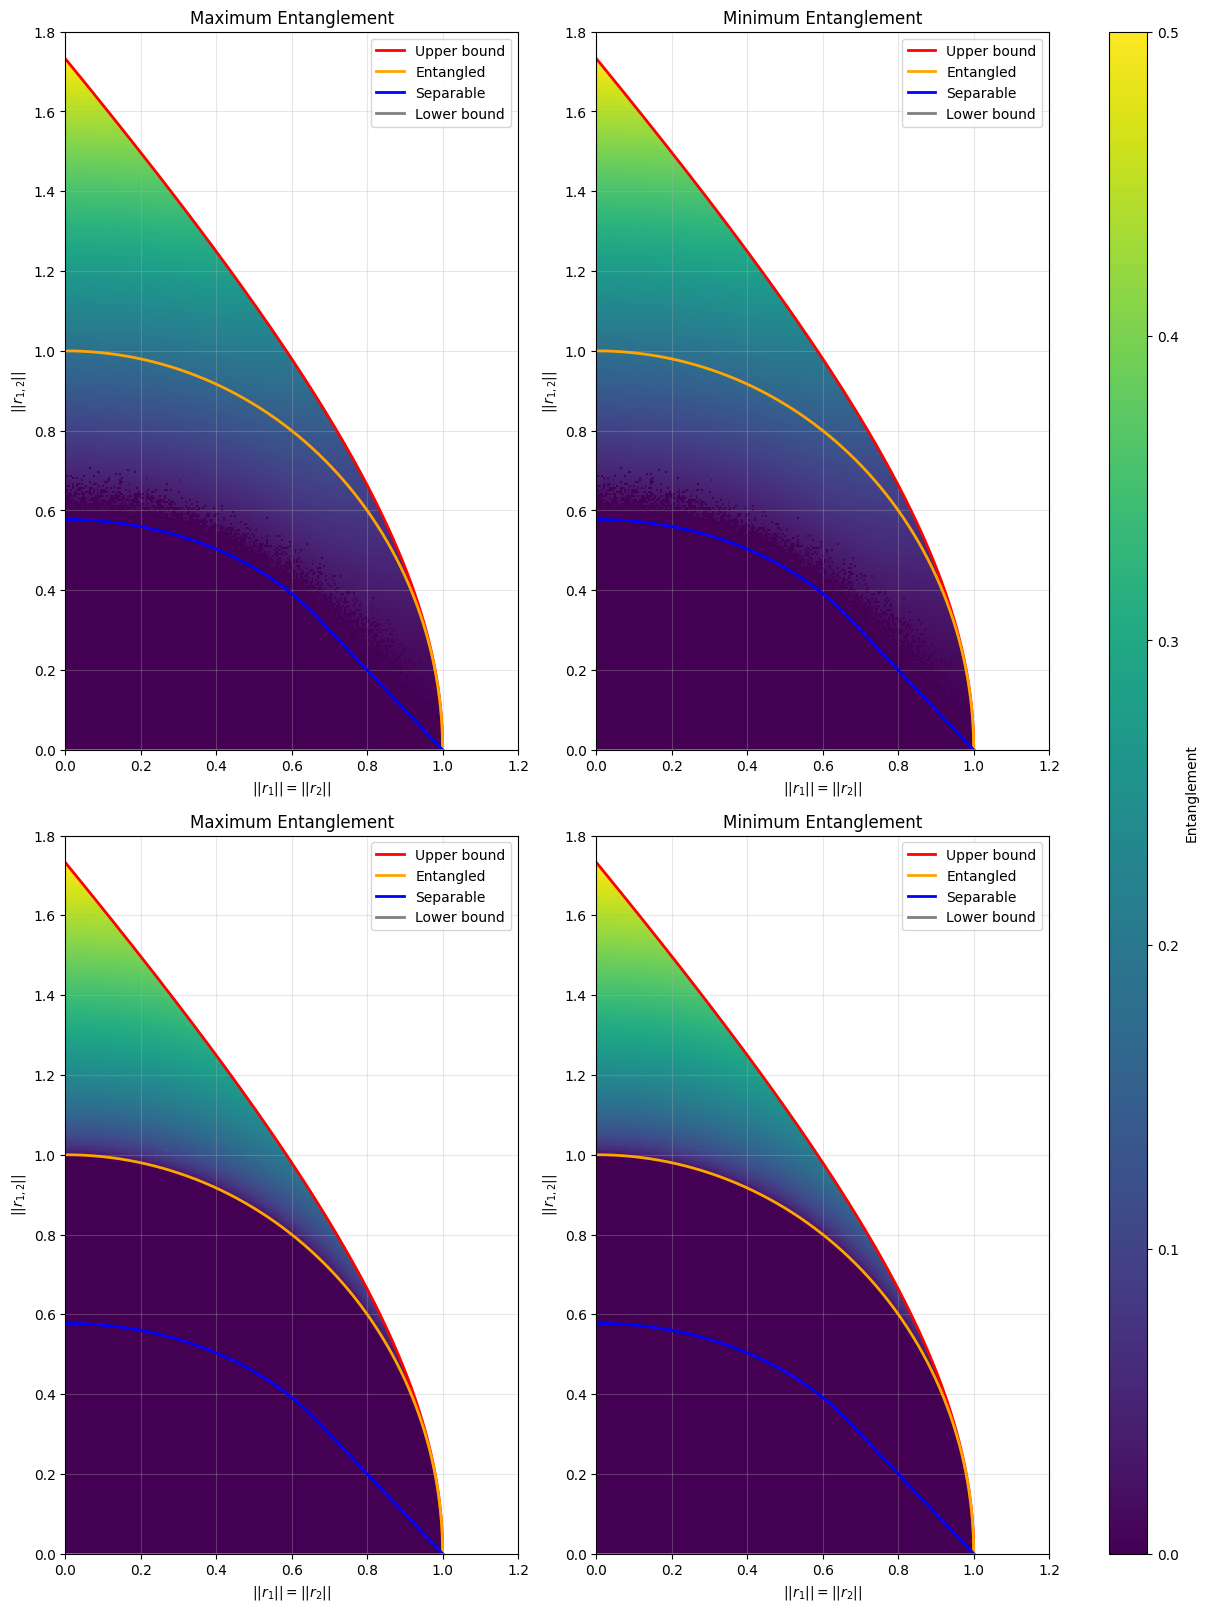

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12, 16), constrained_layout=True)

mesh0 = ax[0, 0].pcolormesh(X, Z, ent_max_num, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
mesh0 = ax[0, 1].pcolormesh(X, Z, ent_max_exact, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
mesh1 = ax[1, 0].pcolormesh(X, Z, ent_min_num, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
mesh1 = ax[1, 1].pcolormesh(X, Z, ent_min_exact, shading='auto', cmap='viridis', vmin=0, vmax=0.5)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=40, shrink=1)

cbar.set_ticks(list(np.linspace(0, 0.5, 6)))

ax[0, 0].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.2), ylim = (0, 1.8), title = "Maximum Entanglement")
ax[0, 1].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.2), ylim = (0, 1.8), title = "Minimum Entanglement")
ax[1, 0].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.2), ylim = (0, 1.8), title = "Maximum Entanglement")
ax[1, 1].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.2), ylim = (0, 1.8), title = "Minimum Entanglement")

x = np.linspace(0, 1, 1000)
z_upper = compute_bipartite_region_upper(2, x, 0)
z_ent = compute_bipartite_region_ent(2, x, 0)
z_sep = np.piecewise(x, [x <= 2/3, x > 2/3], [lambda x: np.sqrt(1/6 * (2 - 3 * x**2)), lambda x: 1 - x])
z_lower = compute_bipartite_region_lower([2, 2], x, 0)

ax[0, 0].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 0].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 0].plot(x, z_sep, 'blue', linewidth=2, label='Separable')
ax[0, 0].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

ax[0, 1].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 1].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 1].plot(x, z_sep, 'blue', linewidth=2, label='Separable')
ax[0, 1].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

ax[1, 0].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
ax[1, 0].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
ax[1, 0].plot(x, z_sep, 'blue', linewidth=2, label='Separable')
ax[1, 0].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

ax[1, 1].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
ax[1, 1].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
ax[1, 1].plot(x, z_sep, 'blue', linewidth=2, label='Separable')
ax[1, 1].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

ax[0, 0].legend(loc='upper right')
ax[0, 1].legend(loc='upper right')
ax[1, 0].legend(loc='upper right')
ax[1, 1].legend(loc='upper right')
ax[0, 0].grid(True, alpha=0.3)
ax[0, 1].grid(True, alpha=0.3)
ax[1, 0].grid(True, alpha=0.3)
ax[1, 1].grid(True, alpha=0.3)

plt.show()